Load our dataset and prepare minibatches

In [87]:
print('start')
import cv2
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/My Drive/Cybr486Project/Dataset'

class PreprocessToMNIST:
    def __call__(self, img):
        # convert grayscale
        img = img.convert("L")
        # normalize
        img = np.array(img).astype(np.float32) / 255.0

        # Invert colors if black on white
        if img.mean() > 0.5:
            img = 1 - img
        

        # Find white pixels, compute bound of number, and crop it to match MNIST 20x20 bounds
        mask = img > 0.1
        coords = np.argwhere(mask)
        if coords.size == 0:
            return Image.fromarray(np.zeros((28, 28), dtype=np.uint8))
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0)

        cropped = img[y0:y1+1, x0:x1+1]
        resized = cv2.resize(cropped, (20, 20), interpolation=cv2.INTER_AREA)

        # Pad 20x20
        new_img = np.zeros((28, 28), dtype=np.float32)
        new_img[4:24, 4:24] = resized

        return Image.fromarray((new_img * 255).astype(np.uint8))


print('normalize transform starting')
normalize_transform = torchvision.transforms.Compose([
    PreprocessToMNIST(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.1307,), std=(0.3081,))
    ])

start
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
normalize transform starting


In [88]:

print('normalize transform ending')
print('load datasets start')
train_dataset = torchvision.datasets.MNIST(root="./CYBR486FINALPROJECT",transform=normalize_transform,download=True)
dataset = torchvision.datasets.ImageFolder(data_dir, transform=normalize_transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
custom_train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
print('load datasets end')

normalize transform ending
load datasets start
load datasets end


Visualize and analyze our data

******
VISUALIZE DATA SET


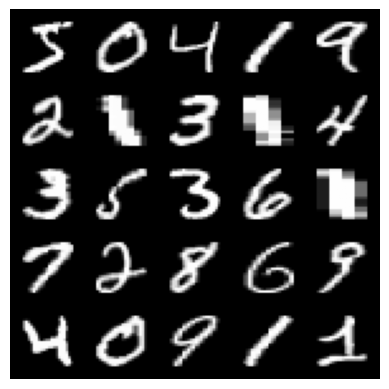

*******
ANALYZE DATASET


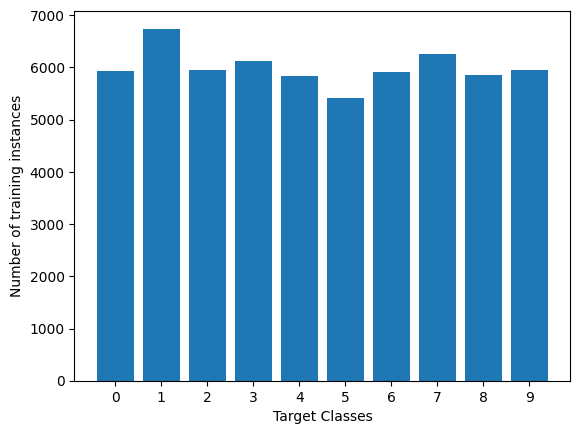

In [90]:
#prepare minibatches
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size)
custom_train_loader = torch.utils.data.DataLoader(custom_train_dataset, batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,shuffle=False)

#visualization
print("******\nVISUALIZE DATA SET")
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images * 0.3081 + 0.1307
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], padding=1, nrow=5).numpy(), (1, 2, 0)),cmap="gray")
plt.axis('off')
plt.show()



#analyze dataset
print("*******\nANALYZE DATASET")
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

Build our model

In [91]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32,
                        kernel_size=3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32,
                        kernel_size=3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=32, out_channels=64,
                        kernel_size=3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=64, out_channels=64,
                        kernel_size=3, padding='same'),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Flatten(),
            torch.nn.LazyLinear(128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 10)
        )
    def forward(self,x):
        return self.model(x)

In [92]:
#gpu acceleration
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


Train our model

In [ ]:
num_epochs = 20
learning_rate = 0.001
weight_decay = 1e-4
model = CNN().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)


#train
print("\n\n*****************\nTRAINING STARTING\n****************")
train_loss_list = []
custom_loss_list = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss_list.append(train_loss / len(train_loader))
    print(f"Training loss = {train_loss_list[-1]}")

    train_loss = 0
    for images, labels in custom_train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    custom_loss_list.append(train_loss / len(custom_train_loader))
    print(f"Custom Training loss = {custom_loss_list[-1]}")
print("\n\n*****************\nTRAINING DONE\n****************")
torch.save(model.state_dict(), f"/content/drive/My Drive/Cybr486Project/Models/C2-2xF3FM32P2-128.pt")
plt.plot(range(1, num_epochs + 1), train_loss_list)
plt.plot(range(1, num_epochs + 1),custom_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()

total_y_true = []
total_y_pred = []
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()


print(f"C2-2xF3FM32P2-128, Test set accuracy = {100 * test_acc / len(test_dataset)} %")
num_images = 5
y_true_name = [names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()



*****************
TRAINING STARTING
****************
Epoch 1/20: Training loss = 0.14847487472311738
Custom Training loss = 1.03800368309021
Epoch 2/20: Training loss = 0.04737551336749679
Custom Training loss = 0.8878882527351379
Epoch 3/20: Training loss = 0.03475723507271042
Custom Training loss = 0.36610961705446243
Epoch 4/20: Training loss = 0.024188621967049816
Custom Training loss = 0.42132294178009033
Epoch 5/20: Training loss = 0.020168154096284637
Custom Training loss = 0.2886214852333069
Epoch 6/20: Training loss = 0.01735773649198294
Custom Training loss = 0.24926429241895676
Epoch 7/20: 

: 

Test our model